# Benchmark Statistics: Ball / Tray / Box Tasks

Loads docx-recommended files, verifies best-file selection, prints cost keys, and produces per-task 1×3 figures (SR / Comp Time / Task Time, all 4 batches) plus a single-row overview (SR + Task Time, b=250 & b=500).

**Method order is consistent across all tasks: Hand-Tuned → Bayesian → PPO → ARS.**  
**Task Time uses NPZ `total_time` (end-to-end wall-clock seconds), excludes episode 0 (warm-up), and is computed only over successful episodes.**

In [1]:
import os, glob, sys, site
from pathlib import Path
from IPython.display import display, Image

os.environ['MPLBACKEND'] = 'Agg'
import numpy as np
try:
    import matplotlib.pyplot as plt
except ImportError:
    # Fall back to compatible system packages if user-site Matplotlib and NumPy mismatch.
    user_site = site.getusersitepackages()
    if user_site in sys.path:
        sys.path.remove(user_site)
    for module_name in list(sys.modules):
        if module_name == 'matplotlib' or module_name.startswith('matplotlib.'):
            del sys.modules[module_name]
    import matplotlib.pyplot as plt

# Compatibility for object arrays saved by NumPy 2.x when this notebook runs on NumPy 1.x.
sys.modules.setdefault('numpy._core', np.core)
sys.modules.setdefault('numpy._core.multiarray', np.core.multiarray)

BASE = Path(os.path.abspath('.'))
print('Working directory:', BASE)


Working directory: /home/aks-lab/Downloads/100_trial_data-20260625T075449Z-3-004/100_trial_data


In [2]:
# eval_default_bayesian_b250_n20_20260528_091855.npz
# eval_default_bayesian_b500_n20_20260528_093010.npz


## 1. File Definitions from .docx Recommendations

Method order is **Hand-Tuned, Bayesian, PPO, ARS** for every task.  
"Policy" in the original ball-task folders = ARS. PPO is loaded separately from the selected best-evaluation/validation checkpoint folders.

In [3]:
import re

METHOD_TOKENS = {
    'Hand-Tuned': 'handtuned',
    'Bayesian': 'bayesian',
    'PPO': 'ppo',
    'ARS': 'policy',
}

TASK_ROOTS = {
    'Ball Lift': ['eval_sweep_100_ball_lift'],
    'Box Lift': ['eval_sweep_100_box_lift_3'],
    'Tray Push': ['eval_sweep_100_tray_push_8'],
}

# PPO checkpoint IDs requested for comparison: Ball 4951, Box 5005, Tray Push 5307.
# Use the best evaluation/validation checkpoint variant for each task.
PPO_PATTERNS = {
    'Ball Lift': 'ppo_results/Ball_lift/ppo4951_best_eval/**/*.npz',
    'Box Lift': 'eval_box_lift_matched_20260923_205507/npz/ppo5005besteval_batch*/*.npz',
    'Tray Push': 'ppo_results/Tray_push/ppo5307_best_val_batch*/*.npz',
}

# Replace only the specified method's source; do not pool old and matched ARS runs.
METHOD_PATTERN_OVERRIDES = {
    'Box Lift': {
        'ARS': 'eval_box_lift_matched_20260923_205507/npz/ars4218_batch*/*.npz',
    },
}

METHOD_COLORS = {
    'Hand-Tuned': '#4C72B0',
    'Bayesian': '#DD8452',
    'ARS': '#55A868',
    'PPO': '#C44E52',
}


def _success_rate(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    return float(d['success'].astype(float).mean())


def _rel_to_base(path_like):
    return str(Path(path_like).resolve().relative_to(BASE.resolve()))


DOC_FILES = {}
all_batches_found = set()
for task_name, roots in TASK_ROOTS.items():
    source_patterns = {'PPO': PPO_PATTERNS[task_name]}
    source_patterns.update(METHOD_PATTERN_OVERRIDES.get(task_name, {}))
    task_cfg = {
        'folders': roots,
        'source_patterns': source_patterns,
        'methods': {m: {} for m in METHOD_TOKENS},
        'candidates': {m: {} for m in METHOD_TOKENS},
    }

    # Scan every NPZ in task folders and group by method + batch.
    for root in roots:
        npz_files = glob.glob(str(BASE / root / 'npz' / '**' / '*.npz'), recursive=True)
        for f_abs in npz_files:
            fname_l = Path(f_abs).name.lower()
            bmatch = re.search(r'batch(\d+)', fname_l)
            if bmatch is None:
                continue
            batch = int(bmatch.group(1))

            method = None
            for method_name, token in METHOD_TOKENS.items():
                if token in fname_l:
                    method = method_name
                    break
            if method is None or method in source_patterns:
                continue

            task_cfg['candidates'][method].setdefault(batch, []).append(_rel_to_base(f_abs))
            all_batches_found.add(batch)

    # Explicit method sources also handle PPO 'policy' and matched ARS filenames.
    for method, pattern in source_patterns.items():
        matched_files = sorted(glob.glob(str(BASE / pattern), recursive=True))
        if not matched_files:
            raise FileNotFoundError(f'{task_name} / {method}: no NPZ files match {pattern}')
        for f_abs in matched_files:
            bmatch = re.search(r'batch(\d+)', Path(f_abs).name.lower())
            if bmatch is None:
                raise ValueError(f'Cannot identify batch size in {f_abs}')
            batch = int(bmatch.group(1))
            task_cfg['candidates'][method].setdefault(batch, []).append(_rel_to_base(f_abs))
            all_batches_found.add(batch)

    # Select best candidate (highest success rate) for each method/batch.
    for method in METHOD_TOKENS:
        for batch, cand_rel in task_cfg['candidates'][method].items():
            scored = []
            for c_rel in sorted(set(cand_rel)):
                c_abs = BASE / c_rel
                try:
                    scored.append((_success_rate(c_abs), c_rel))
                except Exception as e:
                    print(f'[WARN] Failed to load {c_rel}: {e}')

            if not scored:
                continue

            scored.sort(key=lambda x: (-x[0], x[1]))
            task_cfg['methods'][method][batch] = scored[0][1]
            task_cfg['candidates'][method][batch] = [c for _, c in scored]

    DOC_FILES[task_name] = task_cfg

ALL_BATCHES = sorted(all_batches_found)
THREE_BATCHES = [b for b in [250, 500, 750] if b in ALL_BATCHES]
if not THREE_BATCHES:
    THREE_BATCHES = ALL_BATCHES[:3]
OVERVIEW_BATCHES = [b for b in [250, 500] if b in ALL_BATCHES]
if len(OVERVIEW_BATCHES) < 2:
    OVERVIEW_BATCHES = ALL_BATCHES[:2]

print('Tasks:', list(DOC_FILES.keys()))
print('Batches discovered:', ALL_BATCHES)
for task_name, task_cfg in DOC_FILES.items():
    print(f'\n{task_name}:')
    for method in METHOD_TOKENS:
        batches = sorted(task_cfg['methods'][method].keys())
        print(f'  {method:<12} batches found: {batches if batches else "none"}')
        source = task_cfg['source_patterns'].get(method, ', '.join(task_cfg['folders']))
        print(f'    source: {source}')


Tasks: ['Ball Lift', 'Box Lift', 'Tray Push']
Batches discovered: [250, 500, 750, 1000]

Ball Lift:
  Hand-Tuned   batches found: [250, 500, 750, 1000]
    source: eval_sweep_100_ball_lift
  Bayesian     batches found: [250, 500, 750, 1000]
    source: eval_sweep_100_ball_lift
  PPO          batches found: [250, 500, 750, 1000]
    source: ppo_results/Ball_lift/ppo4951_best_eval/**/*.npz
  ARS          batches found: [250, 500, 750, 1000]
    source: eval_sweep_100_ball_lift

Box Lift:
  Hand-Tuned   batches found: [250, 500, 750, 1000]
    source: eval_sweep_100_box_lift_3
  Bayesian     batches found: [250, 500, 750, 1000]
    source: eval_sweep_100_box_lift_3
  PPO          batches found: [250, 500, 750, 1000]
    source: eval_box_lift_matched_20260923_205507/npz/ppo5005besteval_batch*/*.npz
  ARS          batches found: [250, 500, 750, 1000]
    source: eval_box_lift_matched_20260923_205507/npz/ars4218_batch*/*.npz

Tray Push:
  Hand-Tuned   batches found: [250, 500, 750, 1000]
   

## 1.1. CEM Settings of the Methods Used in These Plots

Verified settings for the evaluation files selected by `TASK_ROOTS`, `PPO_PATTERNS`, and `METHOD_PATTERN_OVERRIDES` above. Updated 2026-09-24 for the matched Box ARS/PPO run. This is a snapshot of the current inputs; recheck this table if those sources change. Each row covers all four batch sizes. Method order: **Hand-Tuned → Bayesian → PPO → ARS**.

| Task | Method | CEM batch sizes | Planning horizon (steps) | CEM iterations | Projection iterations | Timestep (s) | Evidence |
|---|---|---|---:|---:|---:|---|---|
| Ball Lift | Hand-Tuned | 250, 500, 750, 1000 | 10 | 2 | 5 | 0.1 | NPZ + evaluation logs |
| Ball Lift | Bayesian | 250, 500, 750, 1000 | 10 | 2 | 5 | 0.1 | NPZ + evaluation logs |
| Ball Lift | PPO 4951 (best eval) | 250, 500, 750, 1000 | 15 | 2 | 5 | 0.1 | NPZ metadata |
| Ball Lift | ARS | 250, 500, 750, 1000 | 10 | 2 | 5 | 0.1 | NPZ + evaluation logs |
| Box Lift | Hand-Tuned | 250, 500, 750, 1000 | 15 | 3 | 5 | 0.1 | NPZ + evaluation logs |
| Box Lift | Bayesian | 250, 500, 750, 1000 | 15 | 3 | 5 | 0.1 | NPZ + evaluation logs |
| Box Lift | PPO 5005 (best eval, matched) | 250, 500, 750, 1000 | 15 | 3 | 5 | 0.1 | Matched NPZ metadata + runtime planner config |
| Box Lift | ARS 4218 (matched) | 250, 500, 750, 1000 | 15 | 3 | 5 | 0.1 | Matched NPZ metadata + runtime planner config |
| Tray Push | Hand-Tuned | 250, 500, 750, 1000 | 10 | 1 | 5 | 0.1 | NPZ + evaluation logs |
| Tray Push | Bayesian | 250, 500, 750, 1000 | 10 | 1 | 5 | 0.1 | NPZ + evaluation logs |
| Tray Push | PPO 5307 (best val) | 250, 500, 750, 1000 | 10 | 1 | 5 | Not recorded | NPZ metadata + planner config |
| Tray Push | ARS | 250, 500, 750, 1000 | 10 | 1 | 5 | 0.1 | NPZ + evaluation logs |

**Sources used by the notebook**

- Ball Hand-Tuned / Bayesian / ARS: `eval_sweep_100_ball_lift/npz/`; corresponding settings in `eval_sweep_100_ball_lift/logs/`.
- Box Hand-Tuned / Bayesian: `eval_sweep_100_box_lift_3/npz/`; corresponding settings in `eval_sweep_100_box_lift_3/logs/`.
- Box ARS 4218: `eval_box_lift_matched_20260923_205507/npz/ars4218_batch*/*.npz`.
- Tray Hand-Tuned / Bayesian / ARS: `eval_sweep_100_tray_push_8/npz/`; corresponding settings in `eval_sweep_100_tray_push_8/logs/`.
- Ball PPO: `ppo_results/Ball_lift/ppo4951_best_eval/**/*.npz`.
- Box PPO 5005 (best eval): `eval_box_lift_matched_20260923_205507/npz/ppo5005besteval_batch*/*.npz`. The `ppo5005best` training variant is not included.
- Tray PPO: `ppo_results/Tray_push/ppo5307_best_val_batch*/*.npz`.

Original-method file/log tokens are `handtuned`, `bayesian`, and `policy` (ARS). Settings were checked across all 20 files/logs per task-method combination. PPO values describe evaluation runtime settings; checkpoint training settings can differ (Box and Tray PPO checkpoint configs record batch size 50).

**Matched Box timing:** Both selected methods have 20 files (five per batch), 20 saved episodes per file, valid nonzero step timings throughout, and explicit units: milliseconds for `step_time` and wall-clock seconds including episode overhead for `total_time`. The evaluator performs one warm-up episode that is not saved. The notebook retains its existing rule of excluding saved episode 0 from Task Time and step 0 from each episode's computation time. Box Hand-Tuned and Bayesian still come from the earlier sweep.

**Interpretation:** Ball PPO has a longer planning horizon than the plotted Ball baselines, so its computation-time comparison uses different MPC workloads. Box and Tray match on the batch sizes, horizon, CEM iterations, and projection iterations listed here; that alone does not establish identical implementations or hardware across all four methods. Tray PPO's timestep is not stored in the inspected NPZ metadata/config fields and is not inferred from other methods. Additional CEM parameters, such as elite count/fraction and smoothing, are not established by this table.

## 2. Cost Keys per Task

Verify correct task data is in each folder by inspecting cost weight keys.

In [4]:
for task_name, task_cfg in DOC_FILES.items():
    sample_file = None
    for method in METHOD_TOKENS:
        method_batches = task_cfg['methods'].get(method, {})
        if method_batches:
            first_batch = sorted(method_batches.keys())[0]
            sample_file = method_batches[first_batch]
            break

    print(f'=== {task_name} ===')
    if sample_file is None:
        print('  No NPZ files found for this task.')
        print()
        continue

    data = np.load(BASE / sample_file, allow_pickle=True)
    print(f'  file     : {sample_file}')
    print(f'  npz keys : {data.files}')

    if 'cost_weight_keys' in data.files:
        keys  = list(data['cost_weight_keys'])
        log_w = data['default_log_weights']
        has_b = 'default_log_bayesian_weights' in data.files
        bay_w = data['default_log_bayesian_weights'] if has_b else None
        hdr   = f'  {"cost key":<35}  {"log_w (default)":>18}'
        if has_b:
            hdr += f'  {"log_w (bayesian)":>18}'
        print(hdr)
        print('  ' + '-' * (74 if has_b else 57))
        for i, k in enumerate(keys):
            row = f'  {k:<35}  {log_w[i]:18.6f}'
            if has_b:
                row += f'  {bay_w[i]:18.6f}'
            print(row)
    elif 'cost_weights_keys' in data.files:
        print('  cost_weights_keys:', list(data['cost_weights_keys']))
    print()


=== Ball Lift ===
  file     : eval_sweep_100_ball_lift/npz/handtuned_batch250/eval_handtuned_batch250_n20_20260624_130752.npz
  npz keys : ['batch_size', 'horizon', 'total_time', 'success', 'reason', 'tray_target', 'step_time', 'theta', 'thetadot', 'task_flag', 'task_id', 'cost_g_pick', 'cost_r_pick', 'cost_g_tray', 'cost_r_tray', 'near_grasp', 'near_target', 'collision', 'cost_weights', 'cem_cost_batch', 'cem_cost_list_batch', 'cost_weight_keys', 'default_log_weights', 'default_log_bayesian_weights', 'used_bayesian_default']
  cost key                                log_w (default)    log_w (bayesian)
  --------------------------------------------------------------------------
  collision                                      5.298317            4.179299
  theta                                         -1.609438           -0.164673
  eef_vel                                       -3.218876           -2.314411
  eef_pos                                        0.405465            1.748289


## 3. Verify: Are the Doc Recommendations the Best Available Files?

In [5]:
def load_stats(fpath):
    d       = np.load(fpath, allow_pickle=True)
    success = d['success'].astype(float)
    ttime   = d['total_time'].astype(float)
    sr      = success.mean()
    mask    = success == 1
    tt      = ttime[mask].mean() if mask.any() else float('nan')
    return sr, tt, int(len(success))

issues = []
for task_name, task_cfg in DOC_FILES.items():
    print(f'\n{"="*62}')
    print(f'  {task_name}')
    print(f'{"="*62}')

    for method in METHOD_TOKENS:
        for batch in ALL_BATCHES:
            candidates = task_cfg['candidates'][method].get(batch, [])
            if not candidates:
                print(f'  [{method:<12} b={batch:4d}]  MISSING: no candidates found')
                continue

            selected_rel = task_cfg['methods'][method][batch]
            cand_stats = sorted(
                [(load_stats(BASE / c)[0], Path(c).name) for c in candidates],
                key=lambda x: -x[0]
            )
            best_sr = cand_stats[0][0]
            sel_sr, _, n_eps = load_stats(BASE / selected_rel)
            is_best = abs(sel_sr - best_sr) < 1e-9
            flag = 'OK' if is_best else '!! SUB-OPTIMAL'

            if not is_best:
                issues.append((task_name, method, batch, selected_rel, sel_sr, cand_stats[0][1], best_sr, n_eps))

            print(
                f'  [{method:<12} b={batch:4d}]  {flag:<16}'
                f'  selected={sel_sr*100:5.1f}%  best={best_sr*100:5.1f}%  ({len(candidates)} file(s), n={n_eps})'
            )
            if not is_best:
                print(f'      selected : {selected_rel}  ({sel_sr*100:5.1f}%)')
                print(f'      best name: {cand_stats[0][1]}  ({best_sr*100:5.1f}%)')

print(f'\n{"="*62}')
if issues:
    print(f'SUMMARY -- {len(issues)} selected file(s) are sub-optimal:')
    for t, m, b, sf, ssr, bf, bsr, n_eps in issues:
        print(f'  {t} / {m} / b={b}  selected={ssr*100:5.1f}%  better={bsr*100:5.1f}%  (n={n_eps})')
else:
    print('All selected files are best (or tied for best) among discovered candidates.')



  Ball Lift
  [Hand-Tuned   b= 250]  OK                selected= 35.0%  best= 35.0%  (5 file(s), n=20)
  [Hand-Tuned   b= 500]  OK                selected= 50.0%  best= 50.0%  (5 file(s), n=20)
  [Hand-Tuned   b= 750]  OK                selected= 65.0%  best= 65.0%  (5 file(s), n=20)
  [Hand-Tuned   b=1000]  OK                selected= 80.0%  best= 80.0%  (5 file(s), n=20)
  [Bayesian     b= 250]  OK                selected=100.0%  best=100.0%  (5 file(s), n=20)
  [Bayesian     b= 500]  OK                selected=100.0%  best=100.0%  (5 file(s), n=20)
  [Bayesian     b= 750]  OK                selected=100.0%  best=100.0%  (5 file(s), n=20)
  [Bayesian     b=1000]  OK                selected=100.0%  best=100.0%  (5 file(s), n=20)
  [PPO          b= 250]  OK                selected=100.0%  best=100.0%  (5 file(s), n=20)
  [PPO          b= 500]  OK                selected=100.0%  best=100.0%  (5 file(s), n=20)
  [PPO          b= 750]  OK                selected=100.0%  best=100.0%  (5 f

## 4. Load All Data

- **Success rate**: all 20 episodes.
- **Task Time**: NPZ `total_time` (end-to-end wall-clock seconds); episodes 1–19 only (episode 0 excluded as warm-up), restricted to successful episodes.
- **Computation time**: mean ms/MPC step, excluding step 0 of each episode and ignoring nonpositive or non-finite timing entries. The current matched Box ARS/PPO files contain valid step timings for all saved episodes.
- **Verified units**: NPZ `total_time` is seconds; `step_time` is milliseconds (also stored identically as `step_time_ms` in Tray PPO files).

In [6]:
def comp_time_stats(step_time_arr):
    ep_means = []
    for ep in step_time_arr:
        arr = np.asarray(ep, dtype=float)
        if len(arr) > 1:
            valid = arr[1:]
            valid = valid[np.isfinite(valid) & (valid > 0)]
            if valid.size:
                ep_means.append(valid.mean())
    if ep_means:
        return float(np.mean(ep_means)), float(np.std(ep_means))
    return float('nan'), float('nan')


data_all = {}
for task_name, task_cfg in DOC_FILES.items():
    data_all[task_name] = {}
    print(f'--- {task_name} ---')

    for method in METHOD_TOKENS:
        data_all[task_name][method] = {}

        for batch in ALL_BATCHES:
            cand_files = task_cfg['candidates'][method].get(batch, [])
            if not cand_files:
                data_all[task_name][method][batch] = {
                    'success_rate':   float('nan'),
                    'task_time_mean': float('nan'),
                    'task_time_std':  float('nan'),
                    'comp_time_mean': float('nan'),
                    'comp_time_std':  float('nan'),
                    'n_success':      0,
                    'n_total':        0,
                    'n_files':        0,
                    'files':          [],
                }
                print(f'  {method:<12} b={batch:4d}  MISSING')
                continue

            sr_vals, tt_vals, ct_vals = [], [], []
            n_success_total, n_total_total = 0, 0

            for fname in cand_files:
                d     = np.load(BASE / fname, allow_pickle=True)
                succ  = d['success'].astype(float)
                ttime = d['total_time'].astype(float)

                # success rate: all episodes
                sr = float(succ.mean())

                # episode wall time: total_time, skip episode 0, successful episodes only
                succ_no0  = succ[1:]
                ttime_no0 = ttime[1:]
                mask_no0  = succ_no0 == 1
                tt_mean = ttime_no0[mask_no0].mean() if mask_no0.any() else float('nan')

                ct_mean, _ = comp_time_stats(d['step_time'])

                sr_vals.append(sr)
                tt_vals.append(float(tt_mean))
                ct_vals.append(float(ct_mean))
                n_success_total += int(mask_no0.sum())
                n_total_total += int(len(succ_no0))

            sr_arr = np.asarray(sr_vals, dtype=float)
            tt_arr = np.asarray(tt_vals, dtype=float)
            ct_arr = np.asarray(ct_vals, dtype=float)

            data_all[task_name][method][batch] = {
                'success_rate':   float(np.nanmean(sr_arr)),
                'task_time_mean': float(np.nanmean(tt_arr)),
                'task_time_std':  float(np.nanstd(tt_arr)),
                'comp_time_mean': float(np.nanmean(ct_arr)),
                'comp_time_std':  float(np.nanstd(ct_arr)),
                'n_success':      int(n_success_total),
                'n_total':        int(n_total_total),
                'n_files':        int(len(cand_files)),
                'files':          list(cand_files),
            }

            print(
                f'  {method:<12} b={batch:4d}  SR={np.nanmean(sr_arr)*100:5.1f}%  '
                f'tt={np.nanmean(tt_arr):6.2f}+/-{np.nanstd(tt_arr):.2f}s '
                f'({n_success_total}/{n_total_total} excl ep0, files={len(cand_files)})  '
                f'ct={np.nanmean(ct_arr):.2f}ms ct_std={np.nanstd(ct_arr):.2f}ms'
            )
    print()


--- Ball Lift ---
  Hand-Tuned   b= 250  SR= 25.0%  tt=  4.26+/-0.56s (25/95 excl ep0, files=5)  ct=24.73ms ct_std=0.06ms
  Hand-Tuned   b= 500  SR= 36.0%  tt=  6.12+/-0.47s (35/95 excl ep0, files=5)  ct=29.39ms ct_std=0.40ms
  Hand-Tuned   b= 750  SR= 59.0%  tt=  5.49+/-0.27s (56/95 excl ep0, files=5)  ct=35.00ms ct_std=0.22ms
  Hand-Tuned   b=1000  SR= 61.0%  tt=  6.45+/-0.49s (60/95 excl ep0, files=5)  ct=42.58ms ct_std=0.28ms
  Bayesian     b= 250  SR= 94.0%  tt=  2.06+/-0.11s (89/95 excl ep0, files=5)  ct=24.06ms ct_std=0.12ms
  Bayesian     b= 500  SR= 98.0%  tt=  2.19+/-0.07s (93/95 excl ep0, files=5)  ct=29.51ms ct_std=0.17ms
  Bayesian     b= 750  SR= 97.0%  tt=  2.39+/-0.09s (93/95 excl ep0, files=5)  ct=35.00ms ct_std=0.20ms
  Bayesian     b=1000  SR= 98.0%  tt=  2.77+/-0.08s (93/95 excl ep0, files=5)  ct=42.42ms ct_std=0.24ms
  PPO          b= 250  SR= 99.0%  tt=  2.83+/-0.05s (94/95 excl ep0, files=5)  ct=31.81ms ct_std=0.06ms
  PPO          b= 500  SR= 97.0%  tt=  3.48+/-

  ARS          b= 500  SR= 97.0%  tt=  2.96+/-0.18s (92/95 excl ep0, files=5)  ct=29.48ms ct_std=0.06ms
  ARS          b= 750  SR= 97.0%  tt=  3.48+/-0.19s (92/95 excl ep0, files=5)  ct=35.37ms ct_std=0.17ms
  ARS          b=1000  SR= 99.0%  tt=  3.69+/-0.22s (94/95 excl ep0, files=5)  ct=42.31ms ct_std=0.25ms

--- Box Lift ---
  Hand-Tuned   b= 250  SR= 12.0%  tt=  5.66+/-0.69s (11/95 excl ep0, files=5)  ct=60.21ms ct_std=0.34ms
  Hand-Tuned   b= 500  SR=  8.0%  tt=  5.69+/-0.13s (7/95 excl ep0, files=5)  ct=70.87ms ct_std=0.47ms
  Hand-Tuned   b= 750  SR= 42.0%  tt=  7.00+/-0.64s (39/95 excl ep0, files=5)  ct=87.94ms ct_std=1.02ms
  Hand-Tuned   b=1000  SR= 28.0%  tt=  8.34+/-0.07s (26/95 excl ep0, files=5)  ct=109.47ms ct_std=0.88ms
  Bayesian     b= 250  SR= 26.0%  tt=  6.69+/-0.87s (25/95 excl ep0, files=5)  ct=59.34ms ct_std=0.35ms
  Bayesian     b= 500  SR= 38.0%  tt=  7.37+/-0.89s (37/95 excl ep0, files=5)  ct=70.81ms ct_std=1.11ms
  Bayesian     b= 750  SR= 36.0%  tt=  9.53+/-

  Hand-Tuned   b= 500  SR= 25.0%  tt= 14.81+/-2.58s (24/95 excl ep0, files=5)  ct=44.91ms ct_std=0.12ms


  Hand-Tuned   b= 750  SR= 30.0%  tt= 15.83+/-1.89s (28/95 excl ep0, files=5)  ct=51.06ms ct_std=0.08ms


  Hand-Tuned   b=1000  SR= 33.0%  tt= 16.46+/-2.50s (31/95 excl ep0, files=5)  ct=55.58ms ct_std=0.29ms
  Bayesian     b= 250  SR= 32.0%  tt= 15.61+/-1.95s (31/95 excl ep0, files=5)  ct=40.67ms ct_std=0.06ms
  Bayesian     b= 500  SR= 31.0%  tt= 12.99+/-1.34s (29/95 excl ep0, files=5)  ct=45.06ms ct_std=0.09ms
  Bayesian     b= 750  SR= 35.0%  tt= 14.61+/-1.42s (34/95 excl ep0, files=5)  ct=51.06ms ct_std=0.09ms
  Bayesian     b=1000  SR= 33.0%  tt= 16.03+/-1.15s (31/95 excl ep0, files=5)  ct=55.26ms ct_std=0.08ms
  PPO          b= 250  SR= 43.0%  tt=  3.13+/-0.28s (40/95 excl ep0, files=5)  ct=11.60ms ct_std=0.02ms
  PPO          b= 500  SR= 51.0%  tt=  3.76+/-0.25s (47/95 excl ep0, files=5)  ct=15.74ms ct_std=0.01ms
  PPO          b= 750  SR= 56.0%  tt=  4.89+/-0.33s (53/95 excl ep0, files=5)  ct=21.76ms ct_std=0.01ms
  PPO          b=1000  SR= 49.0%  tt=  5.75+/-0.43s (47/95 excl ep0, files=5)  ct=26.12ms ct_std=0.12ms
  ARS          b= 250  SR= 60.0%  tt=  9.07+/-0.98s (58/95 excl 

## 5. Per-Task Figures (All 4 Batch Sizes)

1 row x 3 subplots: Success Rate / Computation Time / Task Time.  
Single legend at the top of each figure.

Saved: /home/aks-lab/Downloads/100_trial_data-20260625T075449Z-3-004/100_trial_data/benchmark_ball_lift.png


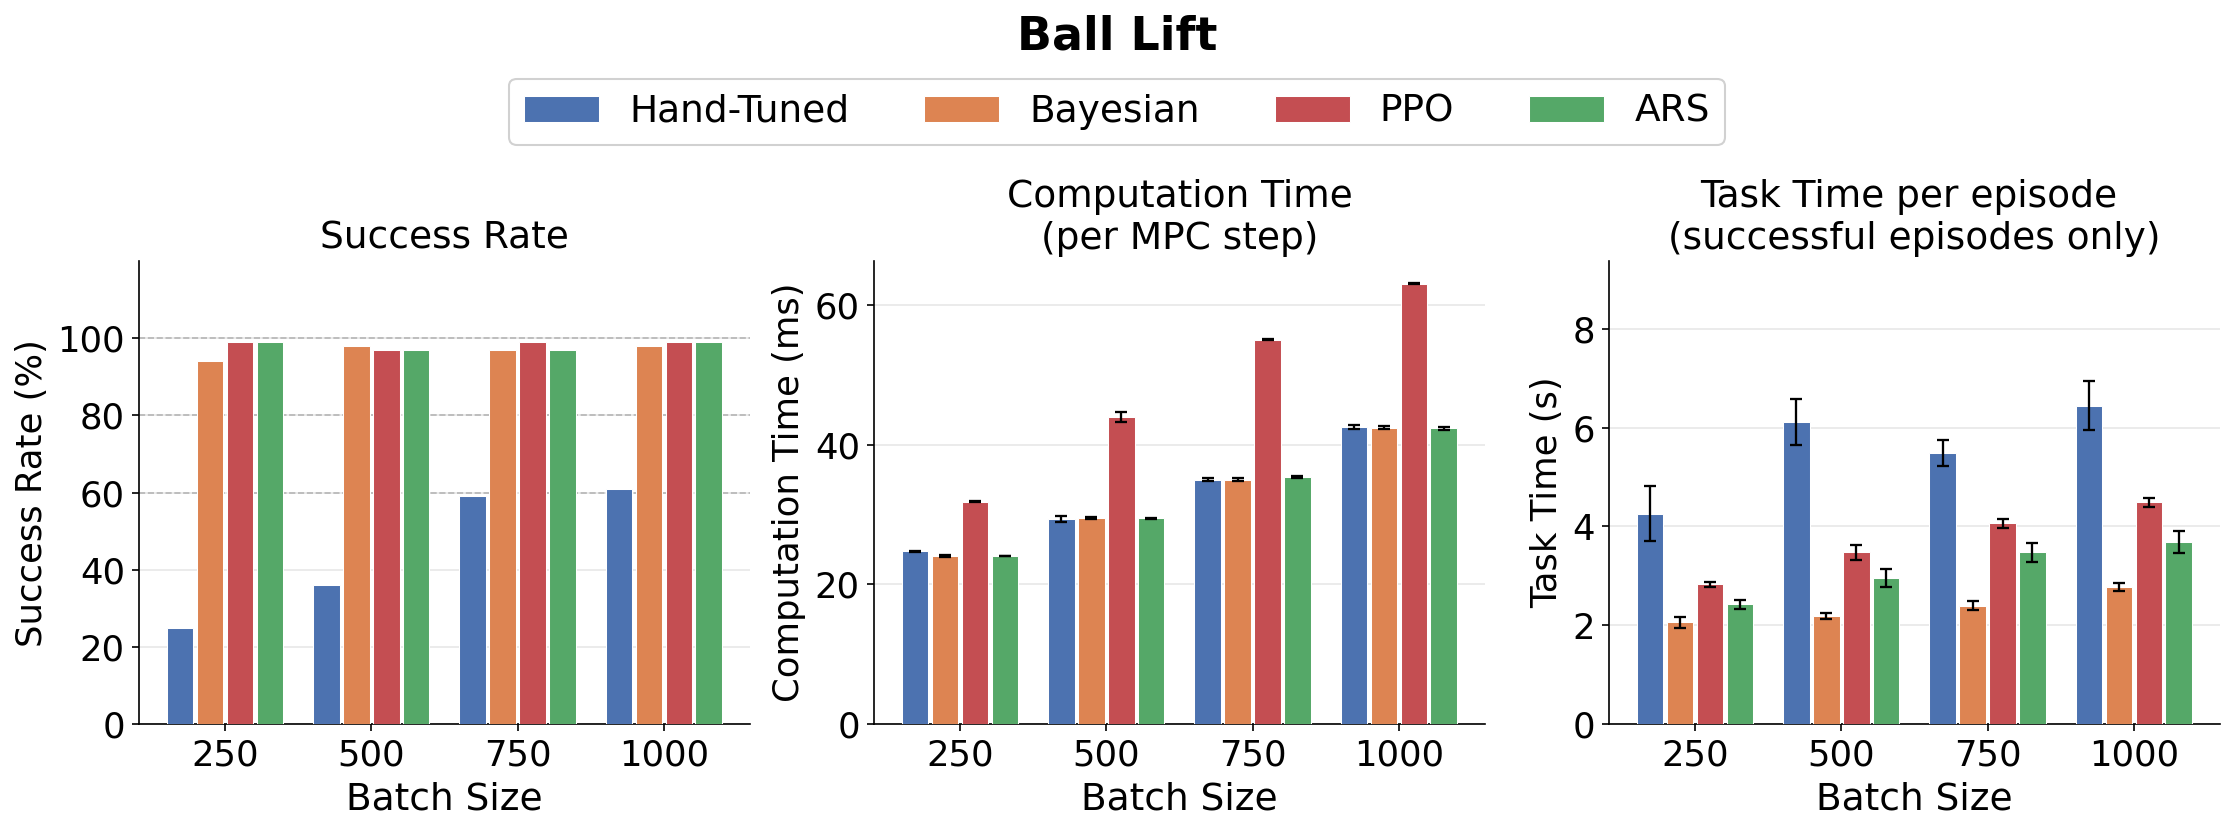

Saved: /home/aks-lab/Downloads/100_trial_data-20260625T075449Z-3-004/100_trial_data/benchmark_box_lift.png


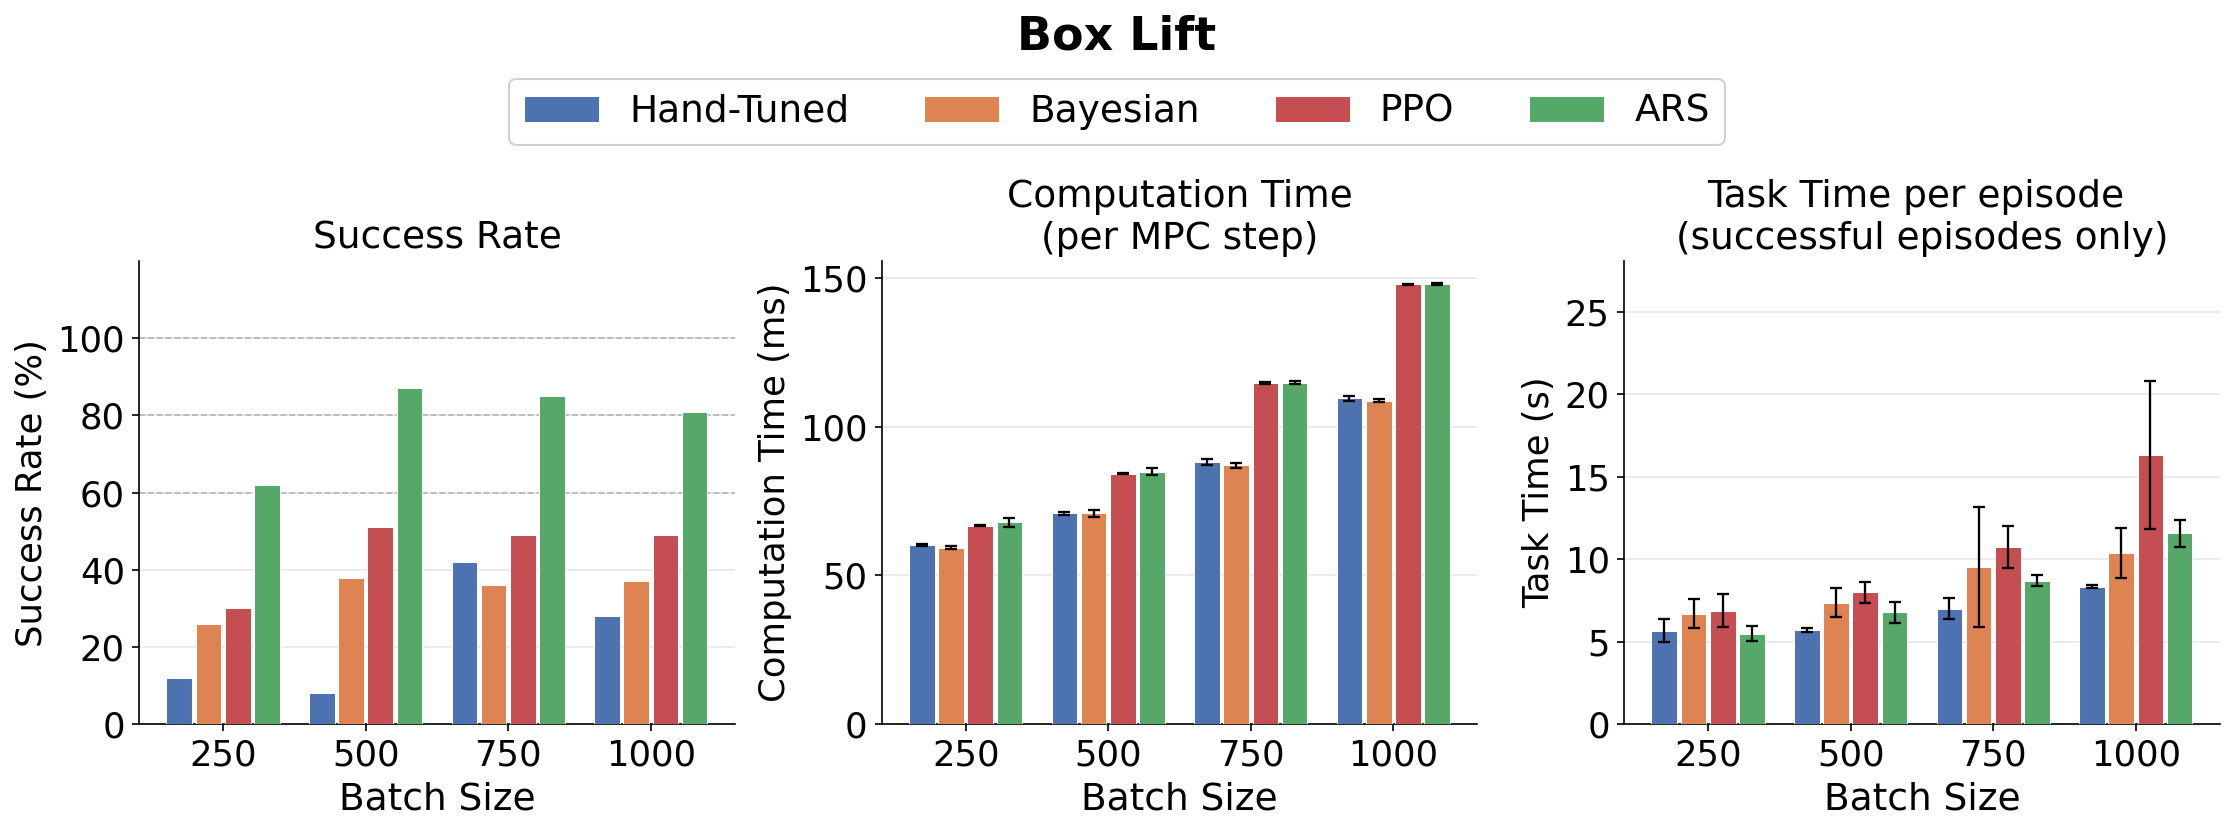

Saved: /home/aks-lab/Downloads/100_trial_data-20260625T075449Z-3-004/100_trial_data/benchmark_tray_push.png


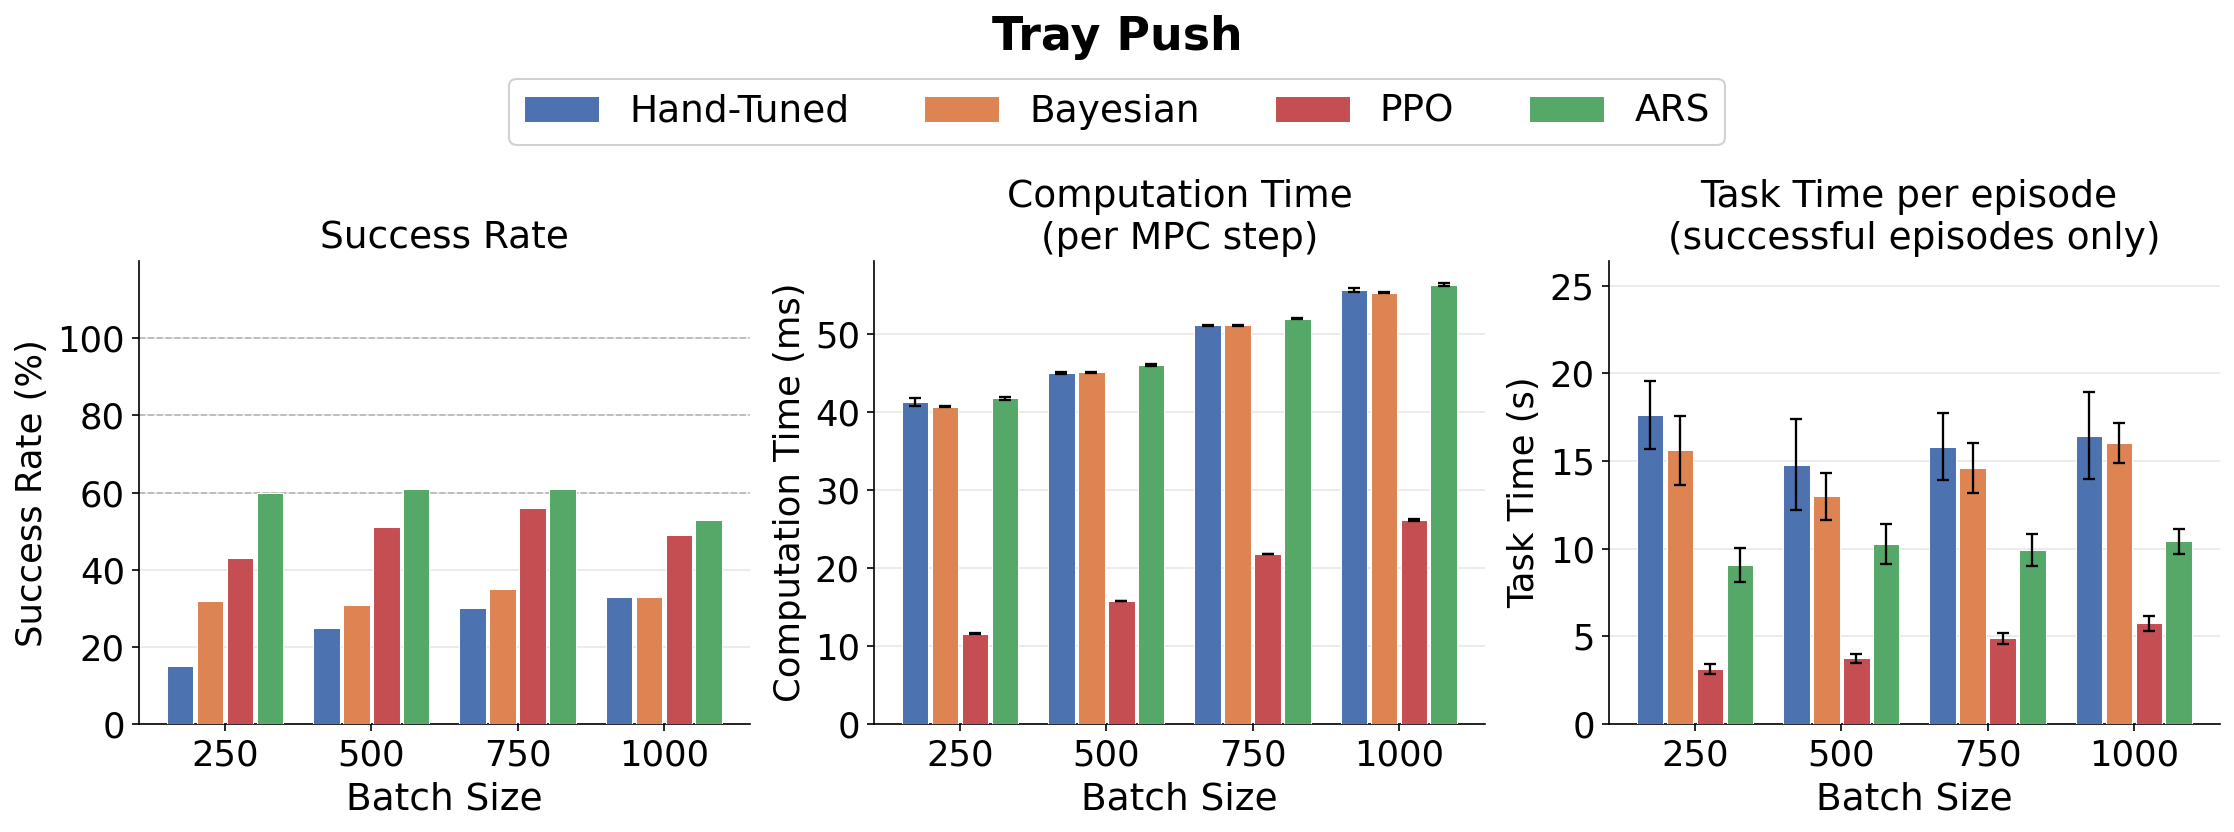

In [7]:
BAR_W = 0.18
GAP   = 0.025

def annotate(ax, bar, label, y_extra=0, fontsize=11, bold=False):
    x  = bar.get_x() + bar.get_width() / 2
    y  = bar.get_height() + y_extra
    kw = {'ha': 'center', 'va': 'bottom', 'fontsize': fontsize}
    if bold:
        kw['fontweight'] = 'bold'
    ax.text(x, y, label, **kw)


def plot_task(task_name, task_data, batch_sizes, save_path=None):
    methods = list(task_data.keys())   # Hand-Tuned, Bayesian, PPO, ARS
    n_m     = len(methods)
    offsets = [(i - (n_m - 1) / 2) * (BAR_W + GAP) for i in range(n_m)]
    x_base  = np.arange(len(batch_sizes))

    fig, (ax_sr, ax_ct, ax_tt) = plt.subplots(1, 3, figsize=(15, 5))

    legend_handles = []
    for m_idx, method in enumerate(methods):
        col  = METHOD_COLORS[method]
        x    = x_base + offsets[m_idx]
        sr   = [task_data[method][b]['success_rate'] * 100 for b in batch_sizes]
        ct_m = [task_data[method][b]['comp_time_mean']     for b in batch_sizes]
        ct_s = [task_data[method][b]['comp_time_std']      for b in batch_sizes]
        tt_m = [task_data[method][b]['task_time_mean']     for b in batch_sizes]
        tt_s = [task_data[method][b]['task_time_std']      for b in batch_sizes]
        ns   = [task_data[method][b]['n_success']          for b in batch_sizes]

        # success rate
        bars = ax_sr.bar(x, sr, width=BAR_W, color=col, edgecolor='white',
                         linewidth=0.5, zorder=3)
        legend_handles.append(bars)

        # computation time
        ax_ct.bar(x, ct_m, width=BAR_W, color=col, edgecolor='white',
                  linewidth=0.5, zorder=3,
                  yerr=ct_s, capsize=3, error_kw={'elinewidth': 1.1, 'capthick': 1.1})

        # episode wall time from total_time (ep0 excluded)
        for i, (v, s, n) in enumerate(zip(tt_m, tt_s, ns)):
            xi = x[i]
            if np.isnan(v) or n == 0:
                ax_tt.bar(xi, 0.3, width=BAR_W, color=col, alpha=0.25,
                          hatch='///', edgecolor='gray', linewidth=0.6)
            else:
                ax_tt.bar(xi, v, width=BAR_W, color=col,
                          edgecolor='white', linewidth=0.5, zorder=3,
                          yerr=s, capsize=3, error_kw={'elinewidth': 1.1, 'capthick': 1.1})

    for ax in (ax_sr, ax_ct, ax_tt):
        ax.set_xticks(x_base)
        ax.set_xticklabels([f'{b}' for b in batch_sizes], fontsize=17)
        ax.set_xlabel('Batch Size', fontsize=18)
        ax.tick_params(axis='y', labelsize=17)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', alpha=0.3, zorder=0)

    ax_sr.set_title('Success Rate', fontsize=18)
    ax_sr.set_ylabel('Success Rate (%)', fontsize=17)
    ax_sr.set_ylim(0, 120)
    ax_sr.set_yticks(range(0, 101, 20))
    ax_sr.axhline(100, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax_sr.axhline(80, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax_sr.axhline(60, color='gray', lw=0.8, ls='--', alpha=0.5)

    ax_ct.set_title('Computation Time\n(per MPC step)', fontsize=18)
    ax_ct.set_ylabel('Computation Time (ms)', fontsize=17)

    ax_tt.set_title('Task Time per episode \n(successful episodes only)', fontsize=18)
    ax_tt.set_ylabel('Task Time (s)', fontsize=17)
    all_tt = [task_data[m][b]['task_time_mean'] for m in methods for b in batch_sizes
              if not np.isnan(task_data[m][b]['task_time_mean'])]
    all_ts = [task_data[m][b]['task_time_std']  for m in methods for b in batch_sizes
              if not np.isnan(task_data[m][b]['task_time_std'])]
    if all_tt:
        raw_top = max(m + s for m, s in zip(all_tt, all_ts))
        ax_tt.set_ylim(0, min(raw_top * 1.35, max(all_tt) * 2.5))

    # single legend at top centre
    fig.legend(legend_handles, methods,
               loc='upper center', ncol=n_m, fontsize=18,
               bbox_to_anchor=(0.5, 1.04), frameon=True, framealpha=0.9)
    fig.suptitle(task_name, fontsize=22, fontweight='bold', y=1.10)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
        display(Image(filename=str(save_path)))
    plt.close(fig)


TASK_ORDER = ['Ball Lift', 'Box Lift', 'Tray Push']
task_names = [t for t in TASK_ORDER if t in data_all]

for task_name in task_names:
    safe = task_name.lower().replace(' ', '_')
    plot_task(task_name, data_all[task_name], ALL_BATCHES,
              save_path=BASE / f'benchmark_{safe}.png')


## 6. Single-Row Overview — All Tasks, b=250 & b=500, SR + Task Time

1 row x 6 subplots. Single shared legend at the top.

Saved: /home/aks-lab/Downloads/100_trial_data-20260625T075449Z-3-004/100_trial_data/benchmark_overview_single_row.png


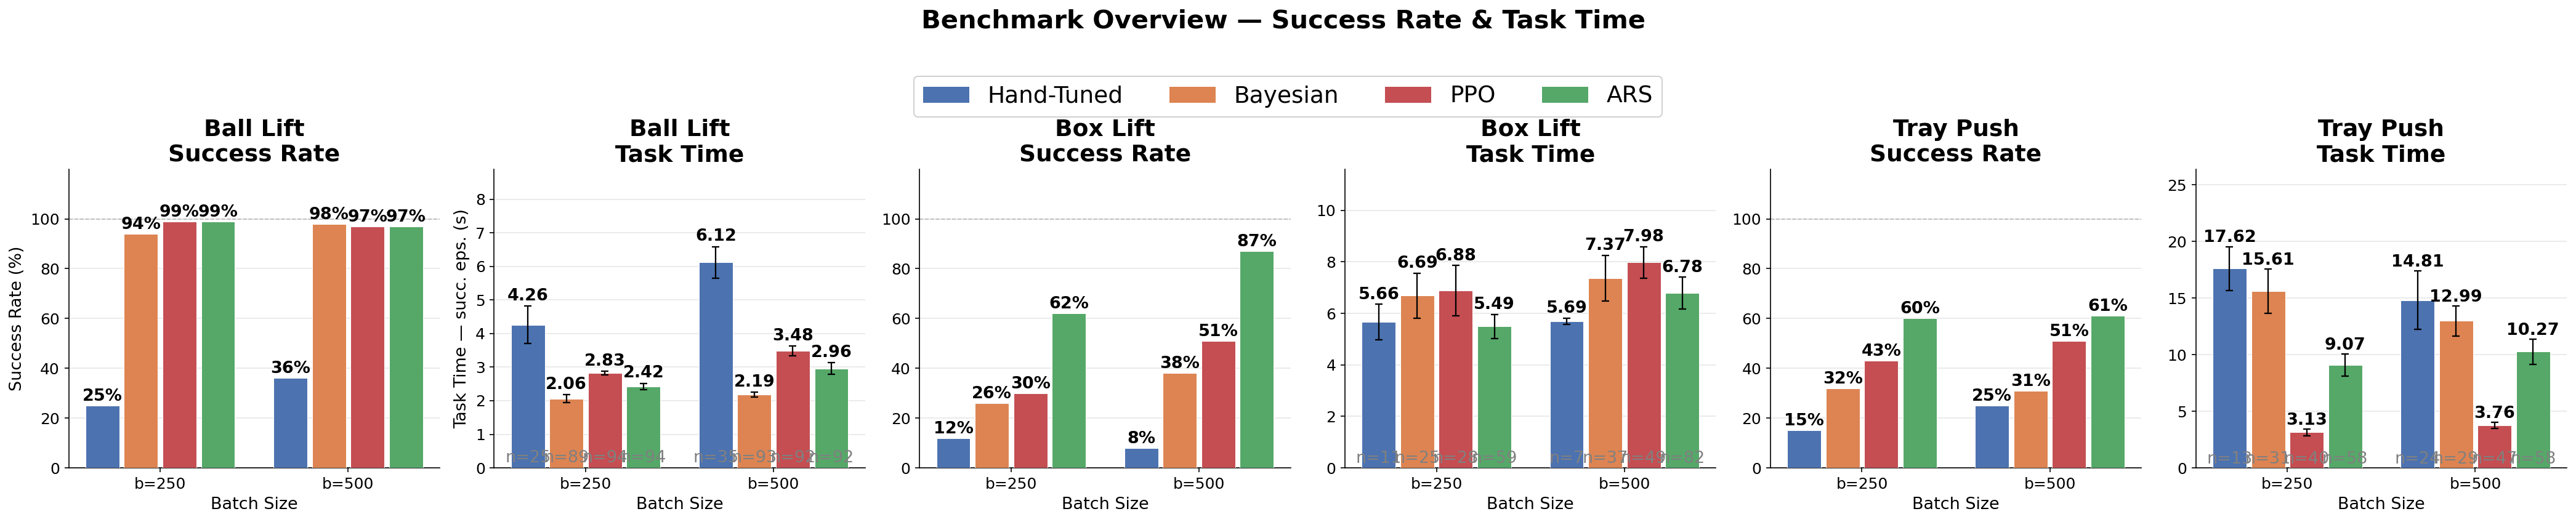

In [8]:
fig, axes = plt.subplots(1, len(task_names) * 2, figsize=(28, 5))

METHOD_ORDER = ['Hand-Tuned', 'Bayesian', 'PPO', 'ARS']
legend_patches = [plt.Rectangle((0, 0), 1, 1, fc=METHOD_COLORS[m]) for m in METHOD_ORDER]

for t_idx, task_name in enumerate(task_names):
    task_data = data_all[task_name]
    methods   = list(task_data.keys())   # Hand-Tuned, Bayesian, PPO, ARS
    n_m       = len(methods)
    offsets   = [(i - (n_m - 1) / 2) * (BAR_W + GAP) for i in range(n_m)]
    x_base    = np.arange(len(OVERVIEW_BATCHES))

    ax_sr = axes[t_idx * 2]
    ax_tt = axes[t_idx * 2 + 1]

    for m_idx, method in enumerate(methods):
        col  = METHOD_COLORS[method]
        x    = x_base + offsets[m_idx]
        sr   = [task_data[method][b]['success_rate'] * 100 for b in OVERVIEW_BATCHES]
        tt_m = [task_data[method][b]['task_time_mean']     for b in OVERVIEW_BATCHES]
        tt_s = [task_data[method][b]['task_time_std']      for b in OVERVIEW_BATCHES]
        ns   = [task_data[method][b]['n_success']          for b in OVERVIEW_BATCHES]

        bars = ax_sr.bar(x, sr, width=BAR_W, color=col,
                         edgecolor='white', linewidth=0.5, zorder=3)
        for bar, v in zip(bars, sr):
            annotate(ax_sr, bar, f'{v:.0f}%', y_extra=0.5, fontsize=13, bold=True)

        for i, (v, s, n) in enumerate(zip(tt_m, tt_s, ns)):
            xi = x[i]
            if np.isnan(v) or n == 0:
                ax_tt.bar(xi, 0.3, width=BAR_W, color=col, alpha=0.2,
                          hatch='///', edgecolor='gray', linewidth=0.6)
                ax_tt.text(xi, 0.38, 'n=0', ha='center', va='bottom',
                           fontsize=9, color='gray', style='italic')
            else:
                ax_tt.bar(xi, v, width=BAR_W, color=col,
                          edgecolor='white', linewidth=0.5, zorder=3,
                          yerr=s, capsize=3, error_kw={'elinewidth': 1.1, 'capthick': 1.1})
                ax_tt.text(xi, v + s + 0.06, f'{v:.2f}',
                           ha='center', va='bottom', fontsize=13, fontweight='bold')
                ax_tt.text(xi, 0.05, f'n={n}',
                           ha='center', va='bottom', fontsize=13, color='gray')

    for ax in (ax_sr, ax_tt):
        ax.set_xticks(x_base)
        ax.set_xticklabels([f'b={b}' for b in OVERVIEW_BATCHES], fontsize=12)
        ax.set_xlabel('Batch Size', fontsize=13)
        ax.tick_params(axis='y', labelsize=12)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', alpha=0.3, zorder=0)

    ax_sr.set_title(f'{task_name}\nSuccess Rate', fontsize=18, fontweight='bold')
    ax_sr.set_ylabel('Success Rate (%)' if t_idx == 0 else '', fontsize=13)
    ax_sr.set_ylim(0, 120)
    ax_sr.set_yticks(range(0, 101, 20))
    ax_sr.axhline(100, color='gray', lw=0.8, ls='--', alpha=0.5)

    ax_tt.set_title(f'{task_name}\nTask Time', fontsize=18, fontweight='bold')
    ax_tt.set_ylabel('Task Time — succ. eps. (s)' if t_idx == 0 else '', fontsize=13)
    all_tt = [task_data[m][b]['task_time_mean'] for m in methods for b in OVERVIEW_BATCHES
              if not np.isnan(task_data[m][b]['task_time_mean'])]
    all_ts = [task_data[m][b]['task_time_std']  for m in methods for b in OVERVIEW_BATCHES
              if not np.isnan(task_data[m][b]['task_time_std'])]
    if all_tt:
        raw_top = max(m + s for m, s in zip(all_tt, all_ts))
        ax_tt.set_ylim(0, min(raw_top * 1.35, max(all_tt) * 2.5))

# single shared legend at top centre
fig.legend(legend_patches, METHOD_ORDER,
           loc='upper center', ncol=4, fontsize=18,
           bbox_to_anchor=(0.5, 1.0), frameon=True, framealpha=0.9)
fig.suptitle('Benchmark Overview — Success Rate & Task Time ',
             fontsize=20, fontweight='bold', y=1.12)

plt.tight_layout()
out = BASE / 'benchmark_overview_single_row.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved: {out}')
display(Image(filename=str(out)))
plt.close(fig)


/tmp/ipykernel_774851/3273190931.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.08, 0.09, 1, 0.95])


Saved: /home/aks-lab/Downloads/100_trial_data-20260625T075449Z-3-004/100_trial_data/benchmark_overview_two_rows.png


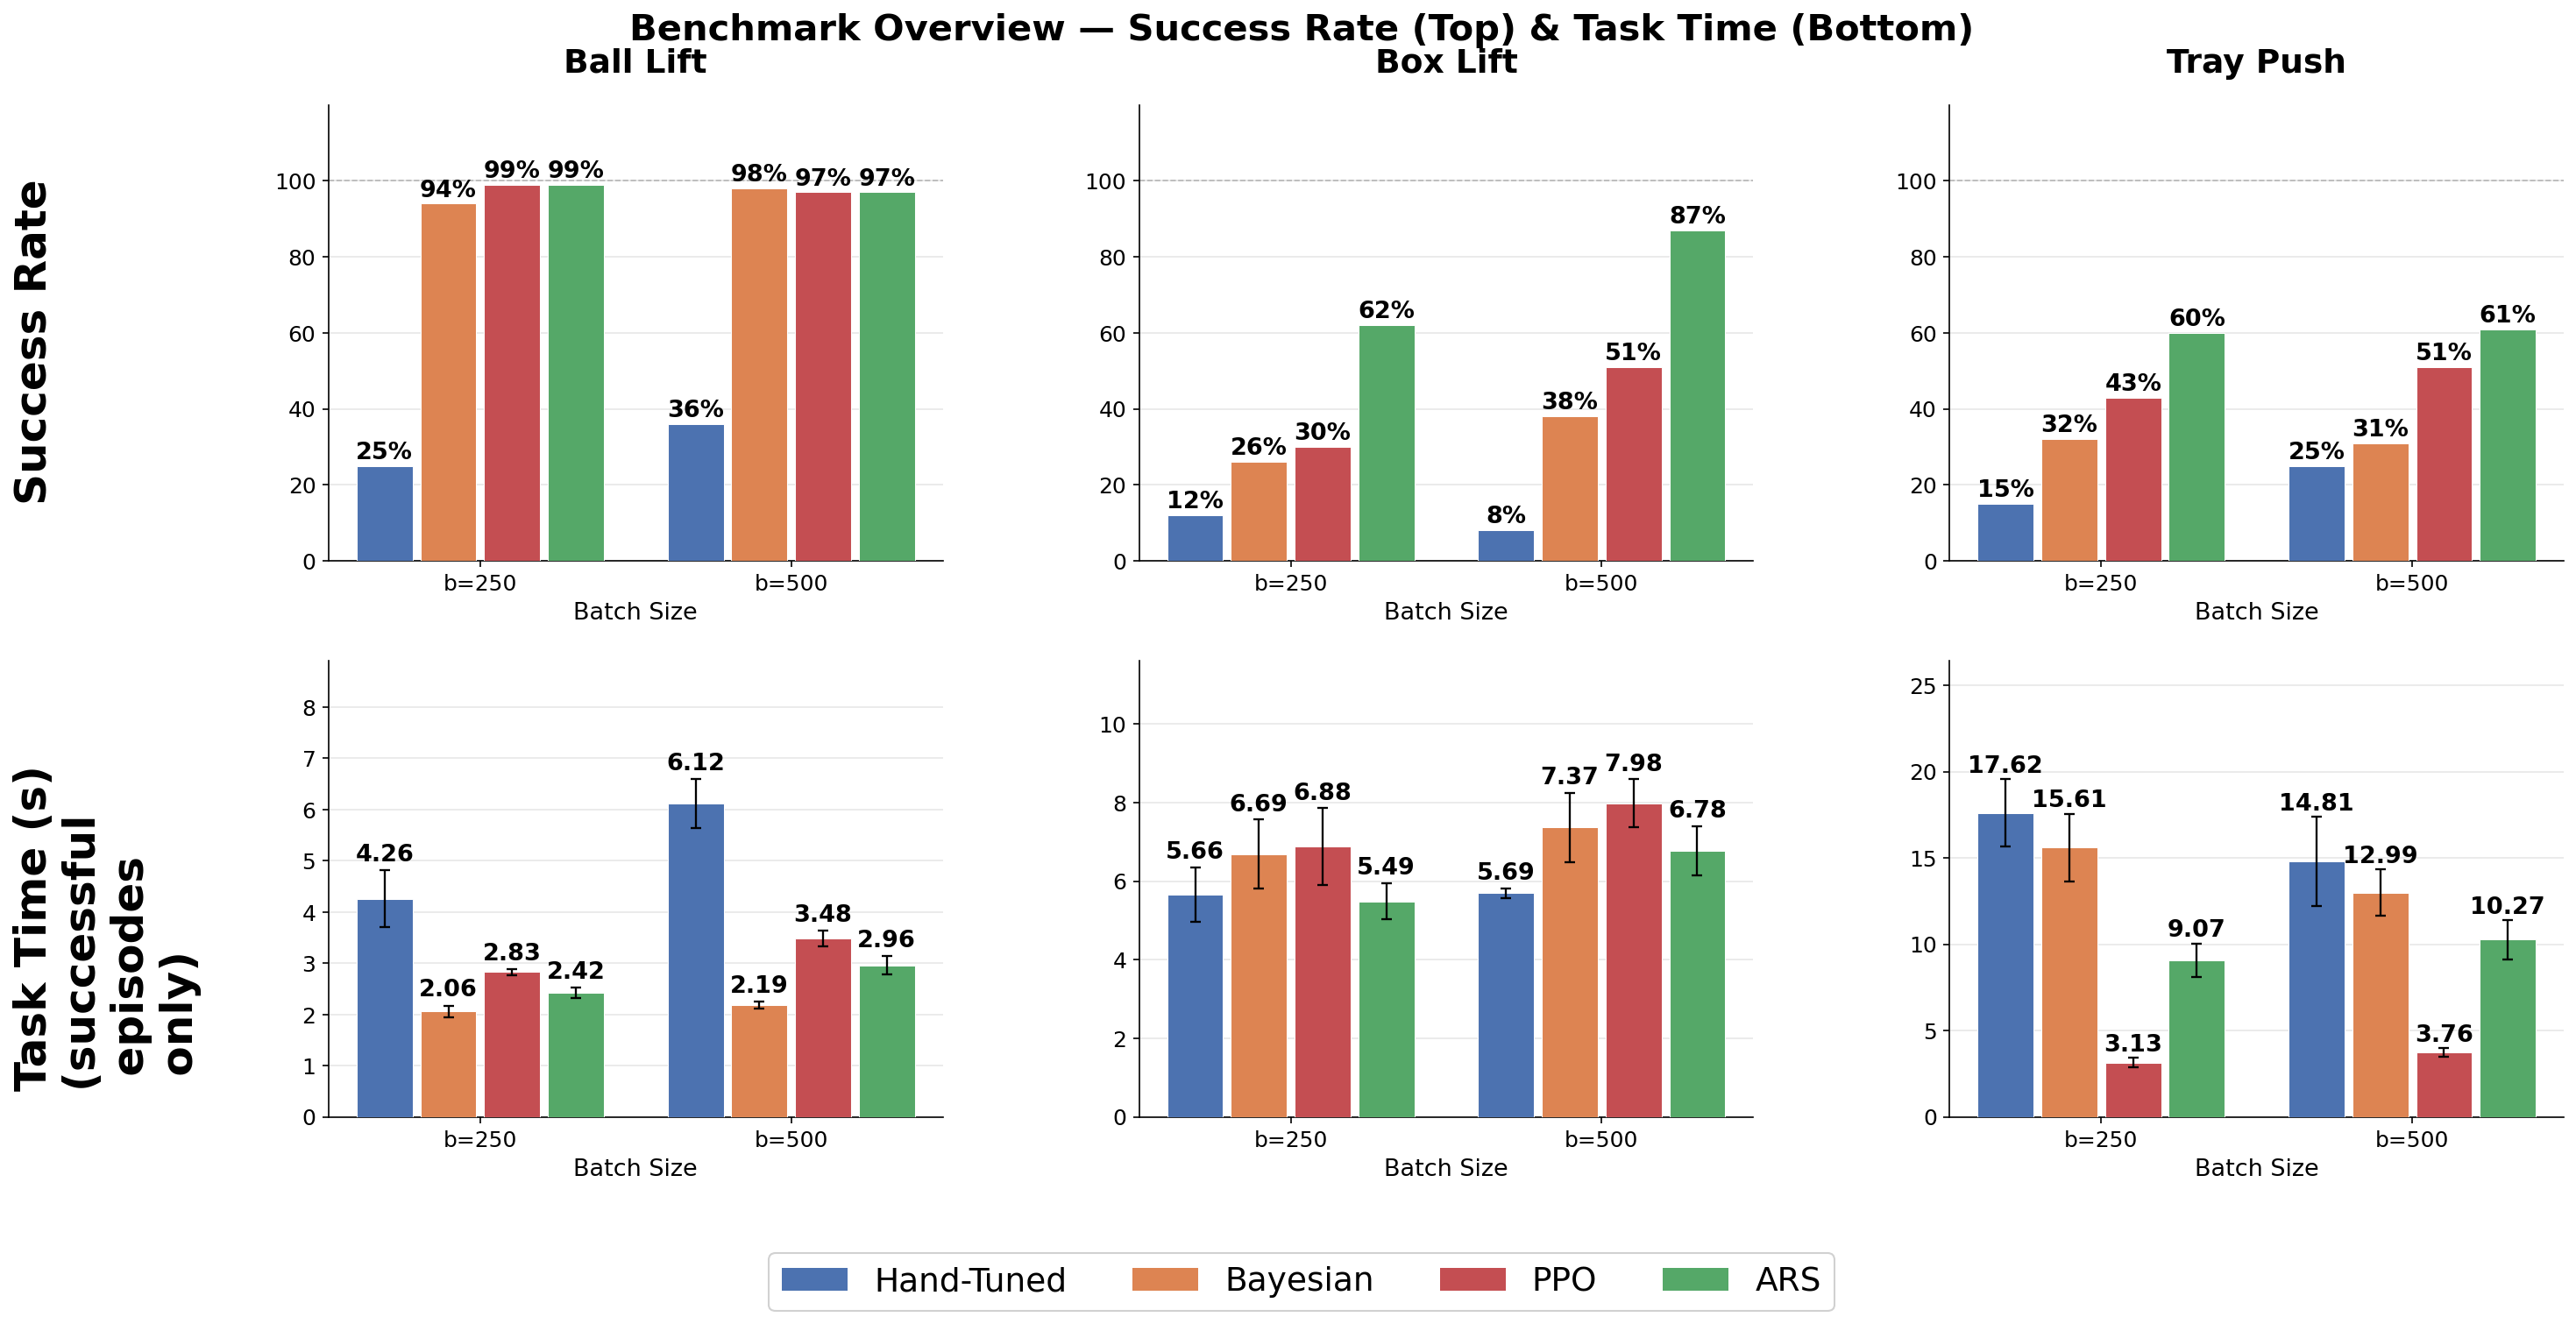

In [9]:
# Plot all tasks in two rows: first row = success rate, second row = task time
# Ensure order: Ball Lift, Box Lift, Tray Push
task_order = ['Ball Lift', 'Box Lift', 'Tray Push']
task_names_sorted = [t for t in task_order if t in task_names]

fig, axes = plt.subplots(2, len(task_names_sorted), figsize=(6 * len(task_names_sorted) + 2, 10), gridspec_kw={'wspace': 0.32, 'hspace': 0.22, 'left': 0.13, 'right': 0.98, 'top': 0.90, 'bottom': 0.13})

legend_patches = [plt.Rectangle((0, 0), 1, 1, fc=METHOD_COLORS[m]) for m in METHOD_ORDER]

for t_idx, task_name in enumerate(task_names_sorted):
    task_data = data_all[task_name]
    methods   = list(task_data.keys())   # Hand-Tuned, Bayesian, PPO, ARS
    n_m       = len(methods)
    offsets   = [(i - (n_m - 1) / 2) * (BAR_W + GAP) for i in range(n_m)]
    x_base    = np.arange(len(OVERVIEW_BATCHES))

    ax_sr = axes[0, t_idx]
    ax_tt = axes[1, t_idx]

    for m_idx, method in enumerate(methods):
        col  = METHOD_COLORS[method]
        x    = x_base + offsets[m_idx]
        sr   = [task_data[method][b]['success_rate'] * 100 for b in OVERVIEW_BATCHES]
        tt_m = [task_data[method][b]['task_time_mean']     for b in OVERVIEW_BATCHES]
        tt_s = [task_data[method][b]['task_time_std']      for b in OVERVIEW_BATCHES]
        ns   = [task_data[method][b]['n_success']          for b in OVERVIEW_BATCHES]

        bars = ax_sr.bar(x, sr, width=BAR_W, color=col,
                         edgecolor='white', linewidth=0.5, zorder=3)
        for bar, v in zip(bars, sr):
            annotate(ax_sr, bar, f'{v:.0f}%', y_extra=0.5, fontsize=13, bold=True)

        for i, (v, s, n) in enumerate(zip(tt_m, tt_s, ns)):
            xi = x[i]
            if np.isnan(v) or n == 0:
                ax_tt.bar(xi, 0.3, width=BAR_W, color=col, alpha=0.2,
                          hatch='///', edgecolor='gray', linewidth=0.6)
                # ax_tt.text(xi, 0.38, 'n=0', ha='center', va='bottom',
                #            fontsize=9, color='gray', style='italic')
            else:
                ax_tt.bar(xi, v, width=BAR_W, color=col,
                          edgecolor='white', linewidth=0.5, zorder=3,
                          yerr=s, capsize=3, error_kw={'elinewidth': 1.1, 'capthick': 1.1})
                ax_tt.text(xi, v + s + 0.08, f'{v:.2f}',
                           ha='center', va='bottom', fontsize=13, fontweight='bold')
                # ax_tt.text(xi, 0.05, f'n={n}',
                #            ha='center', va='bottom', fontsize=13, color='gray')

    # Only set the title at the top row
    ax_sr.set_title(f'{task_name}', fontsize=18, fontweight='bold', pad=18)
    ax_sr.set_ylim(0, 120)
    ax_sr.set_yticks(range(0, 101, 20))
    ax_sr.axhline(100, color='gray', lw=0.8, ls='--', alpha=0.5)

    # Remove title from bottom row
    ax_tt.set_title("")

    for ax in (ax_sr, ax_tt):
        ax.set_xticks(x_base)
        ax.set_xticklabels([f'b={b}' for b in OVERVIEW_BATCHES], fontsize=12)
        ax.set_xlabel('Batch Size', fontsize=13)
        ax.tick_params(axis='y', labelsize=12)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', alpha=0.3, zorder=0)

    all_tt = [task_data[m][b]['task_time_mean'] for m in methods for b in OVERVIEW_BATCHES
              if not np.isnan(task_data[m][b]['task_time_mean'])]
    all_ts = [task_data[m][b]['task_time_std']  for m in methods for b in OVERVIEW_BATCHES
              if not np.isnan(task_data[m][b]['task_time_std'])]
    if all_tt:
        raw_top = max(m + s for m, s in zip(all_tt, all_ts))
        ax_tt.set_ylim(0, min(raw_top * 1.35, max(all_tt) * 2.5))

# Add big y-labels only once at the left side using fig.text
fig.text(0.01, 0.72, 'Success Rate', va='center', ha='left', rotation='vertical', fontsize=24, fontweight='bold')
fig.text(0.01, 0.28, 'Task Time (s) \n(successful  \n episodes \n only)', va='center', ha='left', rotation='vertical', fontsize=24, fontweight='bold')

# Remove y-labels from all axes
for ax in axes.flatten():
    ax.set_ylabel("")

# single shared legend at bottom centre
fig.legend(legend_patches, METHOD_ORDER,
           loc='lower center', ncol=4, fontsize=18,
           bbox_to_anchor=(0.5, -0.03), frameon=True, framealpha=0.9)
fig.suptitle('Benchmark Overview — Success Rate (Top) & Task Time (Bottom)',
             fontsize=20, fontweight='bold', y=0.97)

plt.tight_layout(rect=[0.08, 0.09, 1, 0.95])
out = BASE / 'benchmark_overview_two_rows.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved: {out}')
display(Image(filename=str(out)))
plt.close(fig)
